# Which POIs are most affected by climate change?

In [1]:
from datetime import datetime, timedelta, date
import math

import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
import numpy as np
import orjson
import pandas as pd
import polars as pl
import seaborn as sns
import shapely
from tqdm import tqdm

from wpp import data, db, plot
from wpp.utils import project_root

In [2]:
# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

root = project_root()
db_path = root / "wpp.duckdb"
con = db.connect(db_path)

In [3]:
query = """
    SELECT *
    FROM pois
    WHERE CBSAFP = '33100'
"""
pois = con.sql(query).pl()
pois.head()

<sys>:0: UserWarning: Extension type 'geoarrow.wkb' is not registered; loading as its storage type.

To avoid this warning, register the extension type or set environment variable 'POLARS_UNKNOWN_EXTENSION_TYPE_BEHAVIOR' to 'load_as_storage' or 'load_as_extension'.

In Polars 2.0, the default behavior will change to 'load_as_extension'.


ID_STORE,POI_GEOID,CBSAFP,PERSISTENT_ID,BRAND,LOCATION_NAME,STREET_ADDRESS,CITY,REGION,ISO_COUNTRY_CODE,NAICS_CODE,TOP_CATEGORY,SUB_CATEGORY,OPEN_DATE,CLOSE_DATE,LONGITUDE,LATITUDE,GEOM,CELL_ID
str,str,str,str,str,str,str,str,str,str,str,str,str,date,date,f64,f64,binary,i64
"""10000007""","""120860176003""","""33100""","""A1_NAICS-238320""","""Painting and Wall Covering Con…","""Painting and Wall Covering Con…","""8270 Sw 149Th Ct""","""Miami""","""FL""","""US""","""238320""","""Building Finishing Contractors""","""Painting and Wall Covering Con…",1970-01-01,2038-01-01,-80.434624,25.69067,"b""\x01\x01\x00\x00\x00Bd\xec\xdf\xd0\x1bT\xc0\x0dT\xc6\xbf\xcf\xb09@""",817375
"""10000021""","""120860132011""","""33100""","""A1_NAICS-238320""","""Painting and Wall Covering Con…","""Painting and Wall Covering Con…","""2834 W 75Th Ter""","""Hialeah""","""FL""","""US""","""238320""","""Building Finishing Contractors""","""Painting and Wall Covering Con…",1970-01-01,2038-01-01,-80.340401,25.890989,"b""\x01\x01\x00\x00\x00F\x82\x04\x20\xc9\x15T\xc0\x00\x96\xf0\xdf\x17\xe49@""",811757
"""10000041""","""120110308031""","""33100""","""A1_NAICS-238320""","""Painting and Wall Covering Con…","""Painting and Wall Covering Con…","""1740 Sw 6Th Dr""","""Pompano Beach""","""FL""","""US""","""238320""","""Building Finishing Contractors""","""Painting and Wall Covering Con…",1970-01-01,2038-01-01,-80.133854,26.208924,"b""\x01\x01\x00\x00\x00\x15\x1c^\x10\x91\x08T\xc0\xa9\xdd\xaf\x02|5:@""",800522
"""10000097""","""120111106003""","""33100""","""A1_NAICS-238320""","""Painting and Wall Covering Con…","""Painting and Wall Covering Con…","""3001 Sw 18Th Ter""","""Fort Lauderdale""","""FL""","""US""","""238320""","""Building Finishing Contractors""","""Painting and Wall Covering Con…",1970-01-01,2038-01-01,-80.165093,26.087179,"b""\x01\x01\x00\x00\x00'\x14""\xe0\x90\x0aT\xc06\xe4D`Q\x16:@""",804736
"""10000144""","""120860100172""","""33100""","""A1_NAICS-238320""","""Painting and Wall Covering Con…","""Painting and Wall Covering Con…","""5290 Nw 182Nd St""","""Miami Gardens""","""FL""","""US""","""238320""","""Building Finishing Contractors""","""Painting and Wall Covering Con…",1970-01-01,2038-01-01,-80.287376,25.938471,"b""\x01\x01\x00\x00\x00\x1a\xe9\xfb_d\x12T\xc0?@R\x9f?\xf09@""",808948


In [4]:
query = """
    SELECT
        v.*
    FROM visits v
    JOIN pois p ON v.ID_STORE = p.ID_STORE
    WHERE p.CBSAFP = '33100'
"""
poi_visits = con.sql(query).pl().with_columns(
    pl.col("VISITS_BY_DAY").str.json_decode(pl.List(pl.Int64)).list.to_array(7)
)
poi_visits.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

ID_STORE,DATE_RANGE_START,DATE_RANGE_END,VISITOR_COUNTS,VISIT_COUNTS,VISITS_BY_DAY,VISITS_BY_EACH_HOUR,DISTANCE_FROM_HOME,MEDIAN_DWELL
str,datetime[μs],datetime[μs],"decimal[38,0]","decimal[38,0]","array[i64, 7]",str,f64,f64
"""11995336""",2025-01-06 00:00:00,2025-01-12 00:00:00,2569,2960,"[519, 201, … 297]","""[0,14,14,40,54,107,94,80,80,67…",113770.0,7.0
"""11995337""",2025-01-06 00:00:00,2025-01-12 00:00:00,1030,1030,"[130, 201, … 107]","""[0,0,0,0,0,0,0,13,0,13,39,26,0…",16392.0,3.0
"""11995338""",2025-01-06 00:00:00,2025-01-12 00:00:00,4073,4713,"[271, 639, … 666]","""[14,14,14,14,55,55,163,82,150,…",13020.0,4.0
"""11995339""",2025-01-06 00:00:00,2025-01-12 00:00:00,402,402,"[47, 47, … 36]",null,16310.0,3.0
"""11995340""",2025-01-06 00:00:00,2025-01-12 00:00:00,983,1006,"[142, 130, … 119]","""[0,0,0,0,0,36,24,12,12,48,36,4…",10813.0,3.0


In [5]:
poi_visits_daily = (
    poi_visits
    .explode("VISITS_BY_DAY")
    .with_columns(
        DATE=(
            pl.col("DATE_RANGE_START").dt.date()
            + pl.duration(days=pl.int_range(pl.len()).over("ID_STORE", "DATE_RANGE_START"))
        )
    )
    .rename({"VISITS_BY_DAY": "VISITS"})
    .select("ID_STORE", "DATE", "VISITS")
)
poi_visits_daily.head()

/var/folders/2r/78dg63lx1vg81rz95pp5vkj00000gp/T/ipykernel_5744/1903133896.py:3: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode("VISITS_BY_DAY")


ID_STORE,DATE,VISITS
str,date,i64
"""11995336""",2025-01-06,519
"""11995336""",2025-01-07,201
"""11995336""",2025-01-08,485
"""11995336""",2025-01-09,378
"""11995336""",2025-01-10,319


In [6]:
query = """
    SELECT p.ID_STORE, t.*
    FROM prism_t_daily t
    JOIN pois p ON t.CELL_ID = p.CELL_ID
    WHERE CBSAFP = '33100'
"""
prism = con.sql(query).pl()
prism.head()

ID_STORE,cell_id,DATE,tmean,tmin,tmax
str,i64,date,f32,f32,f32
"""6367445""",775229,2025-01-06,16.824949,10.2324,23.4175
"""9839100""",775230,2025-01-06,17.067949,10.777599,23.358299
"""9691935""",775231,2025-01-06,17.4161,11.449699,23.3825
"""9854796""",775232,2025-01-06,17.7694,12.1269,23.4119
"""9924034""",775233,2025-01-06,18.049648,12.6362,23.463099


In [14]:
df = poi_visits_daily.join(prism, on=["ID_STORE", "DATE"], how="left")

In [16]:
df

ID_STORE,DATE,VISITS,cell_id,tmean,tmin,tmax
str,date,i64,i64,f32,f32,f32
"""11995336""",2025-01-06,519,785053,16.90185,10.100599,23.7031
"""11995336""",2025-01-07,201,785053,18.9702,11.561299,26.379099
"""11995336""",2025-01-08,485,785053,11.62375,8.1884,15.059099
"""11995336""",2025-01-09,378,785053,11.723799,5.2954,18.152199
"""11995336""",2025-01-10,319,785053,10.515249,5.1609,15.869599
…,…,…,…,…,…,…
"""7716688""",2025-12-31,66,814572,14.664849,9.1437,20.185999
"""7716688""",2026-01-01,110,null,null,null,null
"""7716688""",2026-01-02,99,null,null,null,null


<Axes: xlabel='tmean', ylabel='VISITS'>

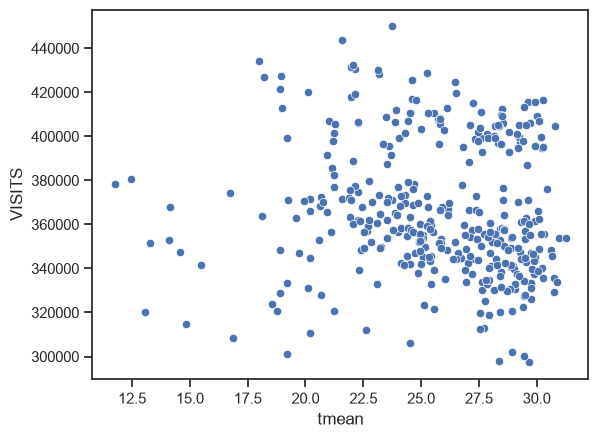

In [25]:
sns.scatterplot(
    df.filter(pl.col("ID_STORE") == "7237699"),
    x="tmean",
    y="VISITS"
)

In [24]:
df.sort("VISITS")

ID_STORE,DATE,VISITS,cell_id,tmean,tmin,tmax
str,date,i64,i64,f32,f32,f32
"""12067167""",2025-01-11,0,776637,15.011299,8.3105,21.712099
"""12067167""",2025-01-12,0,776637,15.7614,10.241099,21.2817
"""12067873""",2025-01-06,0,807546,17.673849,12.7638,22.583899
"""12067873""",2025-01-09,0,807546,15.024651,8.5792,21.4701
"""12067873""",2025-01-12,0,807546,18.61985,13.256599,23.983099
…,…,…,…,…,…,…
"""7237699""",2025-03-01,431704,814570,21.9855,17.358099,26.6129
"""7237699""",2025-03-21,432579,814570,22.0448,15.228299,28.8613
"""7237699""",2025-03-07,434242,814570,17.987949,11.3425,24.6334
